In [ ]:
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from shapely.ops import substring
import numpy as np
from rasterstats import zonal_stats


In [67]:
mrt_path = "../../../datos-notebooks/1.HR-data-bologna/1.5.MRT-prediction/MRT_1m.tif"
utai_path = "../../../datos-notebooks/1.HR-data-bologna/1.5.MRT-prediction/UTAI_1m.tif"
walkable_paths_path = "../../../datos-notebooks/paths_bologna.geojson"
walkable_paths_utai_path = "../../../datos-notebooks/1.HR-data-bologna/1.5.MRT-prediction/walkable_paths_utai.geojson"

### index computing

In [ ]:
# Read raster
with rasterio.open(mrt_path) as src:
    mrt = src.read(1).astype(float)
    profile = src.profile
    crs = src.crs
    transform = src.transform
    nodata = src.nodata

# Mask NoData
if nodata is not None:
    mrt[mrt == nodata] = np.nan

# ------------------------------------------------------------------
# Create thermal adaptability index (1–10)
# 10 = lowest MRT, 1 = highest MRT
# ------------------------------------------------------------------

mrt_min = np.nanmin(mrt)
mrt_max = np.nanmax(mrt)

mrt_norm = (mrt - mrt_min) / (mrt_max - mrt_min) # Normalize to [0, 1]
mrt_norm_inv = 1 - mrt_norm # Invert scale (low MRT = high score)
thermal_index = 1 + 9 * mrt_norm_inv # Scale to [1, 10]
thermal_index_int = np.round(thermal_index) # Round to integers (sectorization)



In [65]:
profile_out = profile.copy()
profile_out.update(
    dtype=rasterio.float32,
    count=1,
    nodata=np.nan
)

with rasterio.open(utai_path, "w", **profile_out) as dst:
    dst.write(thermal_index.astype(np.float32), 1)


In [66]:
with rasterio.open(utai_path) as src:
    thermal_index_int = src.read(1)

plt.figure(figsize=(8, 8))
img = plt.imshow(
    thermal_index_int,
    cmap="coolwarm_r",
    vmin=1,
    vmax=10
)
plt.colorbar(img, label="Thermal Adaptability Index (1–10)")
plt.title("Urban Thermal Adaptability Index ")
plt.axis("off")
plt.show()


MemoryError: Unable to allocate 7.30 GiB for an array with shape (15108, 16204, 4) and data type float64

<Figure size 800x800 with 2 Axes>

### fixing paths layer

In [97]:
gdf = gpd.read_file(walkable_paths_path)

In [ ]:
# CRS
print("CRS:", gdf.crs)

# Geometry type(s)
print("Geometry types:")
print(gdf.geometry.geom_type.value_counts())

In [98]:
# Geometry type(s)
print("Geometry types:")
print(gdf.geometry.geom_type.value_counts())

Geometry types:
LineString    16076
Polygon         317
Name: count, dtype: int64


In [102]:
from shapely.geometry import LineString, MultiLineString, Polygon
gdf_lines = gdf.copy()
def to_lines(geom):
    if geom is None:
        return None
    if geom.geom_type in ["LineString", "MultiLineString"]:
        return geom
    if geom.geom_type == "Polygon":
        return geom.boundary
    if geom.geom_type == "MultiPolygon":
        return geom.boundary
    return None

gdf_lines["geometry"] = gdf_lines.geometry.apply(to_lines)


In [103]:
# Geometry type(s)
print("Geometry types:")
print(gdf_lines.geometry.geom_type.value_counts())

Geometry types:
LineString    16393
Name: count, dtype: int64


In [104]:

gdf_lines = gdf_lines.to_crs(epsg=32632)  # meters
gdf_lines["length_m"] = gdf_lines.geometry.length
gdf_lines = gdf_lines[gdf_lines["length_m"] > 0].copy() # Remove zero-length geometries


In [105]:
# Geometry type(s)
print("Geometry types:")
print(gdf_lines.geometry.geom_type.value_counts())

Geometry types:
LineString    16393
Name: count, dtype: int64


In [ ]:
gdf_lines.head(3)

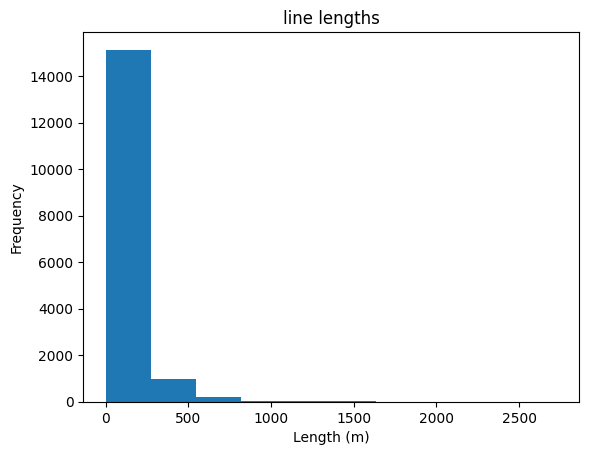

In [107]:
# Histogram of line lengths
plt.hist(gdf_lines["length_m"], bins=10)
plt.xlabel("Length (m)")
plt.ylabel("Frequency")
plt.title("line lengths")
plt.show()


In [108]:
def split_line_max_length(line, max_len=100):
    """
    Split a LineString into segments with max length <= max_len (meters)
    """
    length = line.length
    if length <= max_len:
        return [line]

    distances = np.arange(0, length, max_len)
    segments = []

    for d0, d1 in zip(distances[:-1], distances[1:]):
        segments.append(substring(line, d0, d1))

    # last segment
    segments.append(substring(line, distances[-1], length))

    return segments


In [109]:
rows = []

for idx, row in gdf_lines.iterrows():
    parts = split_line_max_length(row.geometry, max_len=100)

    for geom in parts:
        rows.append({
            **row.drop("geometry"),
            "geometry": geom
        })


In [110]:
gdf_split = gpd.GeoDataFrame(rows, crs=gdf_lines.crs)
gdf_split["length_m"] = gdf_split.geometry.length


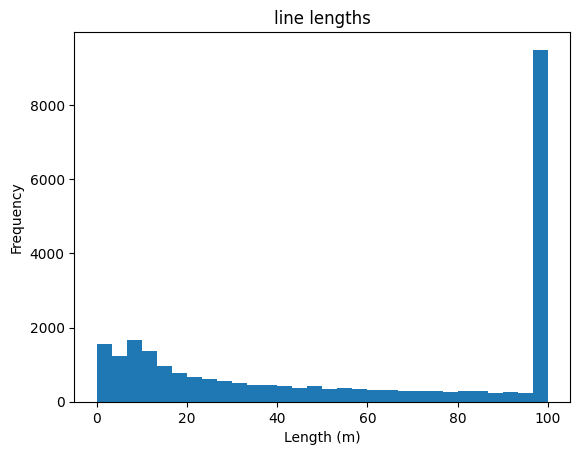

In [111]:
# Histogram of line lengths
plt.hist(gdf_split["length_m"], bins=30)
plt.xlabel("Length (m)")
plt.ylabel("Frequency")
plt.title("line lengths")
plt.show()

In [113]:
# Geometry type(s)
print("Geometry types:")
print(gdf_split.geometry.geom_type.value_counts())

Geometry types:
LineString    25628
Name: count, dtype: int64


### extract index values

In [114]:
with rasterio.open(utai_path) as src:
    raster_crs = src.crs
    raster_transform = src.transform
    raster_nodata = src.nodata


In [115]:
if gdf_lines.crs != raster_crs:
    gdf_lines = gdf_lines.to_crs(raster_crs)


stats = zonal_stats(
    gdf_lines,
    utai_path,
    stats=["median"],
    nodata=raster_nodata,
    geojson_out=False
)

gdf_lines["mrt_median"] = [s["median"] for s in stats]

In [116]:
gdf_lines.to_file(walkable_paths_utai_path, driver="GeoJSON")

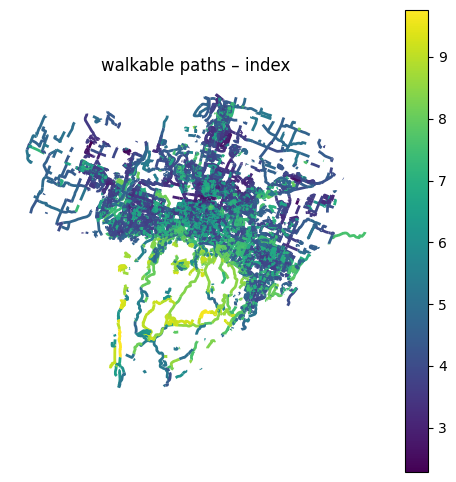

In [118]:
ax = gdf_lines.plot(
    column="mrt_median",
    cmap="viridis",
    legend=True,
    figsize=(6, 6),
    linewidth=2
)

ax.set_title("walkable paths – index")
ax.set_axis_off()
